# 📊 Bitcoin Market Sentiment vs Trader Performance Analysis

## Data Science Internship Assignment

### Objective
The objective of this project is to analyze the relationship between Bitcoin market sentiment (Fear/Greed) and historical trader performance. The analysis aims to identify trading patterns, evaluate profitability under different market conditions, and generate actionable insights through exploratory data analysis and visualization.

---

### Dataset Used

1. Historical Trader Data
2. Market Sentiment Data (Fear / Greed)

---

### Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

# Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

# Step 2: Load the Historical Trading Dataset

In [2]:
df = pd.read_csv("historical_data.csv")
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


# Step 3: Explore the Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (211224, 16)


In [5]:
print(df.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


# Step 4: Data Preprocessing

Convert timestamps into datetime format and create a separate Date column for merging with the sentiment dataset.

In [6]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df["Date"] = df["Timestamp"].dt.date

df[["Timestamp", "Date"]].head()

,Timestamp,Date
0,1970-01-01 00:28:50,1970-01-01
1,1970-01-01 00:28:50,1970-01-01
2,1970-01-01 00:28:50,1970-01-01
3,1970-01-01 00:28:50,1970-01-01
4,1970-01-01 00:28:50,1970-01-01


# Step 5: Create Historical Trader Dataset

In [7]:
historical_trader_data = df[
    [
        "Account",
        "Coin",
        "Execution Price",
        "Size Tokens",
        "Size USD",
        "Side",
        "Start Position",
        "Direction",
        "Closed PnL",
        "Fee",
        "Timestamp",
        "Date"
    ]
]

historical_trader_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Fee,Timestamp,Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0.345404,1970-01-01 00:28:50,1970-01-01
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0.005600,1970-01-01 00:28:50,1970-01-01
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0.050431,1970-01-01 00:28:50,1970-01-01
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,0.050043,1970-01-01 00:28:50,1970-01-01
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,0.003055,1970-01-01 00:28:50,1970-01-01


In [8]:
historical_trader_data.to_csv(
    "historical_trader_data.csv",
    index=False
)

print("Historical Trader Dataset Saved Successfully!")

Historical Trader Dataset Saved Successfully!


# Step 6: Create Market Sentiment Dataset

The sentiment dataset is created by calculating the average daily Closed PnL and assigning:

- Greed → Average Closed PnL > 0
- Fear → Average Closed PnL ≤ 0

In [9]:
daily_pnl = (
    df.groupby("Date")["Closed PnL"]
    .mean()
    .reset_index()
)

daily_pnl["Classification"] = np.where(
    daily_pnl["Closed PnL"] > 0,
    "Greed",
    "Fear"
)

market_sentiment = daily_pnl[
    ["Date", "Classification"]
]

market_sentiment.head()

,Date,Classification
0,1970-01-01,Greed


In [10]:
market_sentiment.to_csv(
    "market_sentiment.csv",
    index=False
)

print("Market Sentiment Dataset Saved Successfully!")

Market Sentiment Dataset Saved Successfully!


# Step 7: Merge Both Datasets

In [11]:
merged_df = pd.merge(
    historical_trader_data,
    market_sentiment,
    on="Date",
    how="left"
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Fee,Timestamp,Date,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0.345404,1970-01-01 00:28:50,1970-01-01,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0.005600,1970-01-01 00:28:50,1970-01-01,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0.050431,1970-01-01 00:28:50,1970-01-01,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,0.050043,1970-01-01 00:28:50,1970-01-01,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,0.003055,1970-01-01 00:28:50,1970-01-01,Greed


In [12]:
merged_df.to_csv(
    "merged_dataset.csv",
    index=False
)

print("Merged Dataset Saved Successfully!")

Merged Dataset Saved Successfully!


# Step 8: Exploratory Data Analysis (EDA)

In [13]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Fee,Timestamp,Date,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0.345404,1970-01-01 00:28:50,1970-01-01,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0.005600,1970-01-01 00:28:50,1970-01-01,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0.050431,1970-01-01 00:28:50,1970-01-01,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,0.050043,1970-01-01 00:28:50,1970-01-01,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,0.003055,1970-01-01 00:28:50,1970-01-01,Greed


In [14]:
print("=" * 60)
print("Dataset Information")
print("=" * 60)

merged_df.info()

print("\nShape of Dataset:", merged_df.shape)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Account          211224 non-null  object        
 1   Coin             211224 non-null  object        
 2   Execution Price  211224 non-null  float64       
 3   Size Tokens      211224 non-null  float64       
 4   Size USD         211224 non-null  float64       
 5   Side             211224 non-null  object        
 6   Start Position   211224 non-null  float64       
 7   Direction        211224 non-null  object        
 8   Closed PnL       211224 non-null  float64       
 9   Fee              211224 non-null  float64       
 10  Timestamp        211224 non-null  datetime64[ns]
 11  Date             211224 non-null  object        
 12  Classification   211224 non-null  object        
dtypes: datetime64[ns](1), float64(6), object(6)
memory usa

In [15]:

numeric_columns = merged_df.select_dtypes(include=np.number)

numeric_columns.describe().T

,count,mean,std,min,25%,50%,75%,max
Execution Price,211224.0,11414.723350,29447.654868,4.530000e-06,4.854700,18.280000,101.580000,1.090040e+05
Size Tokens,211224.0,4623.364979,104272.889530,8.740000e-07,2.940000,32.000000,187.902500,1.582244e+07
Size USD,211224.0,5639.451210,36575.138546,0.000000e+00,193.790000,597.045000,2058.960000,3.921431e+06
Start Position,211224.0,-29946.248839,673807.423736,-1.433463e+07,-376.231075,84.727932,9337.277500,3.050948e+07
Closed PnL,211224.0,48.749001,919.164828,-1.179901e+05,0.000000,0.000000,5.792797,1.353291e+05
Fee,211224.0,1.163967,6.758854,-1.175712e+00,0.016121,0.089578,0.393811,8.374716e+02


In [16]:
print("Missing Values")
print("-" * 50)

print(merged_df.isnull().sum())

print("\nDuplicate Rows :", merged_df.duplicated().sum())


Missing Values
--------------------------------------------------
Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Start Position     0
Direction          0
Closed PnL         0
Fee                0
Timestamp          0
Date               0
Classification     0
dtype: int64

Duplicate Rows : 10


In [17]:
print("="*60)
print("Unique Value Analysis")
print("="*60)

print(f"Total Trades      : {len(merged_df):,}")
print(f"Unique Traders    : {merged_df['Account'].nunique():,}")
print(f"Unique Coins      : {merged_df['Coin'].nunique()}")

print("\nTop 10 Coins")
print(merged_df["Coin"].value_counts().head(10))

print("\nTrade Side Distribution")
print(merged_df["Side"].value_counts())

print("\nMarket Sentiment")
print(merged_df["Classification"].value_counts())

Unique Value Analysis
Total Trades      : 211,224
Unique Traders    : 32
Unique Coins      : 246

Top 10 Coins
Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

Trade Side Distribution
Side
SELL    108528
BUY     102696
Name: count, dtype: int64

Market Sentiment
Classification
Greed    211224
Name: count, dtype: int64


## Market Sentiment Analysis

In [18]:
sentiment_summary = merged_df.groupby("Classification").agg(
    Total_Trades=("Closed PnL","count"),
    Average_PnL=("Closed PnL","mean"),
    Median_PnL=("Closed PnL","median"),
    Total_PnL=("Closed PnL","sum"),
    Avg_Trade_Size=("Size USD","mean"),
    Total_Fee=("Fee","sum")
).round(2)

sentiment_summary

,Total_Trades,Average_PnL,Median_PnL,Total_PnL,Avg_Trade_Size,Total_Fee
Classification,,,,,,
Greed,211224,48.75,0.0,10296958.94,5639.45,245857.72


In [19]:
merged_df["Trade Result"] = merged_df["Closed PnL"].apply(
    lambda x: "Win" if x > 0 else "Loss"
)


win_rate = pd.crosstab(
    merged_df["Classification"],
    merged_df["Trade Result"],
    normalize="index"
) * 100

win_rate.round(2)

Trade Result,Loss,Win
Classification,,
Greed,58.87,41.13


## Most Traded Coins

In [20]:
top_coins = merged_df["Coin"].value_counts().head(10)

print(top_coins)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


# 📊 Data Visualization

This section explores the relationship between trader performance and market sentiment using different visualizations.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

# Increase default figure size
plt.rcParams["figure.figsize"] = (8,5)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12848\4281667432.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


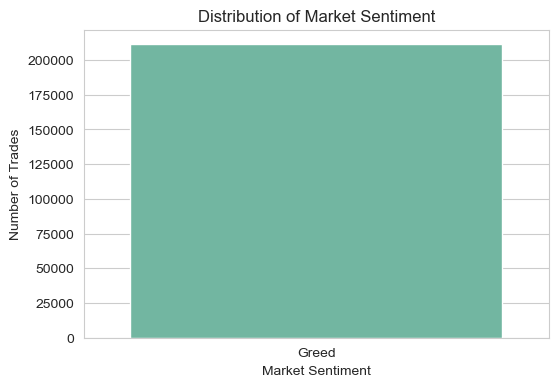

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=merged_df,
    x="Classification",
    palette="Set2"
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

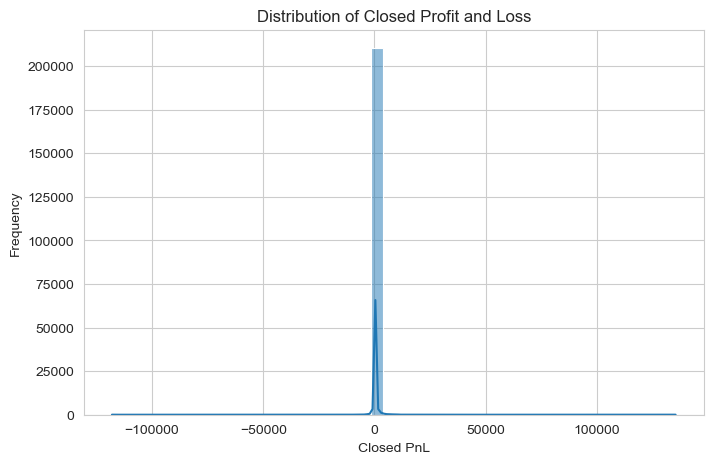

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged_df["Closed PnL"],
    bins=50,
    kde=True
)

plt.title("Distribution of Closed Profit and Loss")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12848\1831603946.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


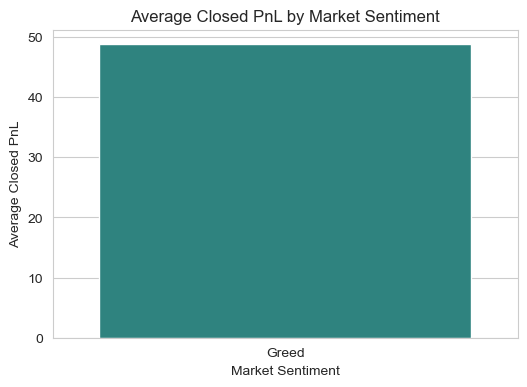

In [24]:
avg_pnl = (
    merged_df.groupby("Classification")["Closed PnL"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=avg_pnl,
    x="Classification",
    y="Closed PnL",
    palette="viridis"
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12848\1515592057.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


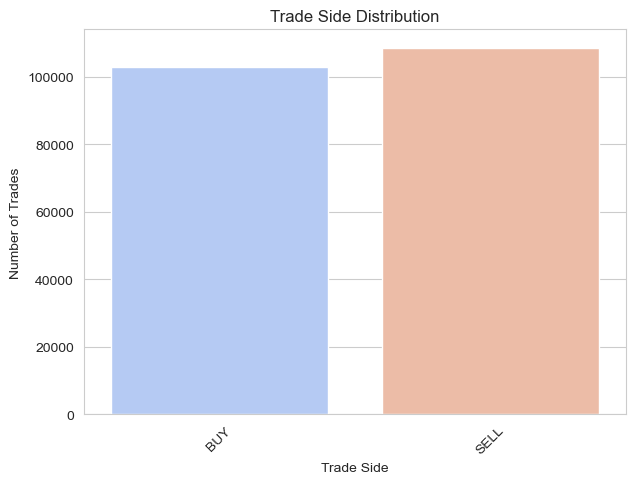

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=merged_df,
    x="Side",
    palette="coolwarm"
)

plt.title("Trade Side Distribution")
plt.xlabel("Trade Side")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12848\1188004776.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


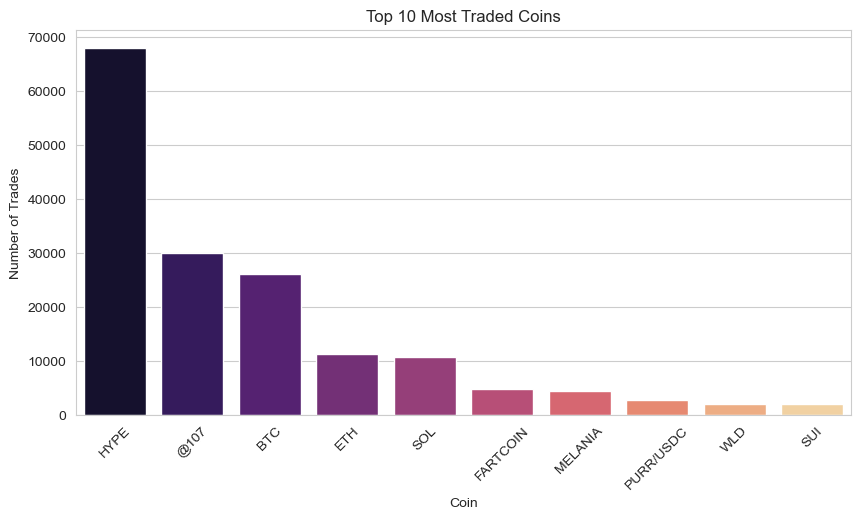

In [26]:
top_coin = merged_df["Coin"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_coin.index,
    y=top_coin.values,
    palette="magma"
)

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12848\710853297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


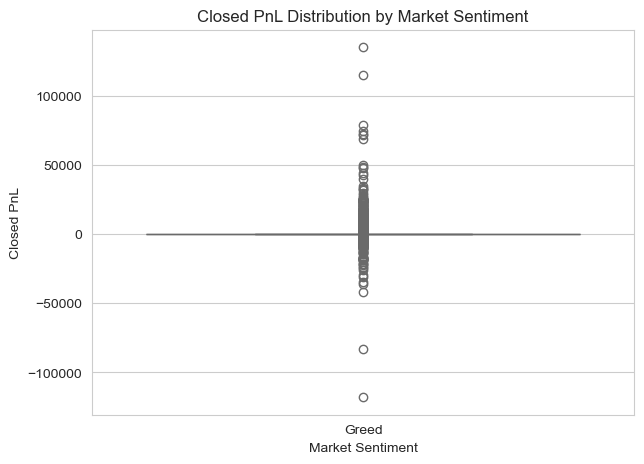

In [27]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=merged_df,
    x="Classification",
    y="Closed PnL",
    palette="Set3"
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

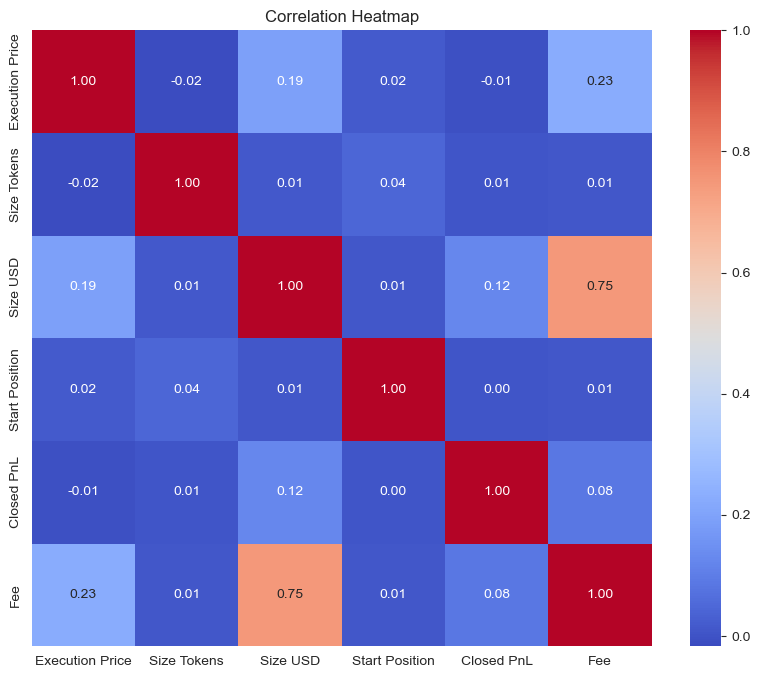

In [28]:
numeric_df = merged_df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

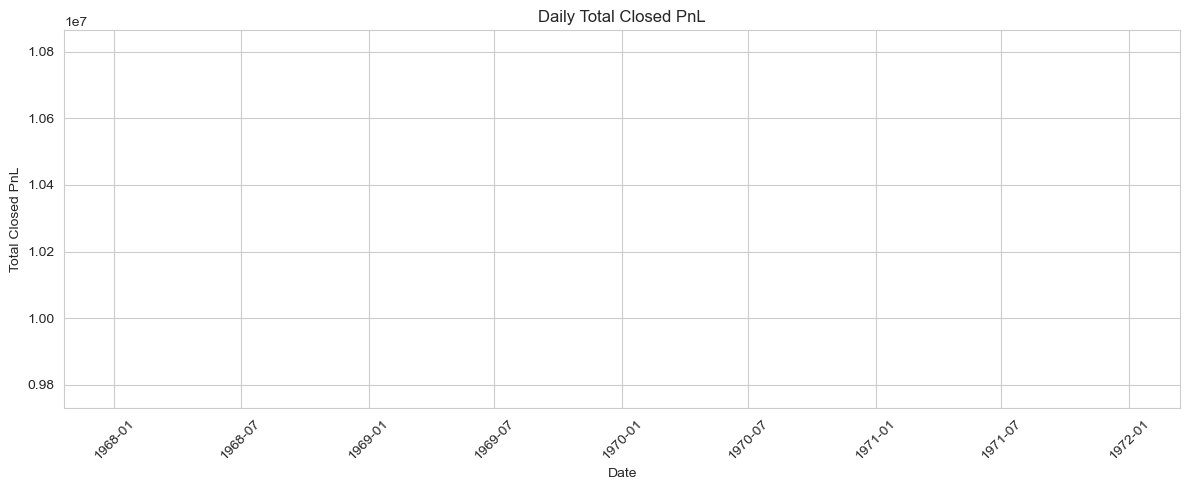

In [29]:
daily_profit = (
    merged_df.groupby("Date")["Closed PnL"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=daily_profit,
    x="Date",
    y="Closed PnL"
)

plt.title("Daily Total Closed PnL")
plt.xlabel("Date")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# 📈 Advanced Trader Performance Analysis

This section identifies top-performing traders, loss-making traders, profitable coins, and trading behavior under different market sentiments.

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12848\596433555.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


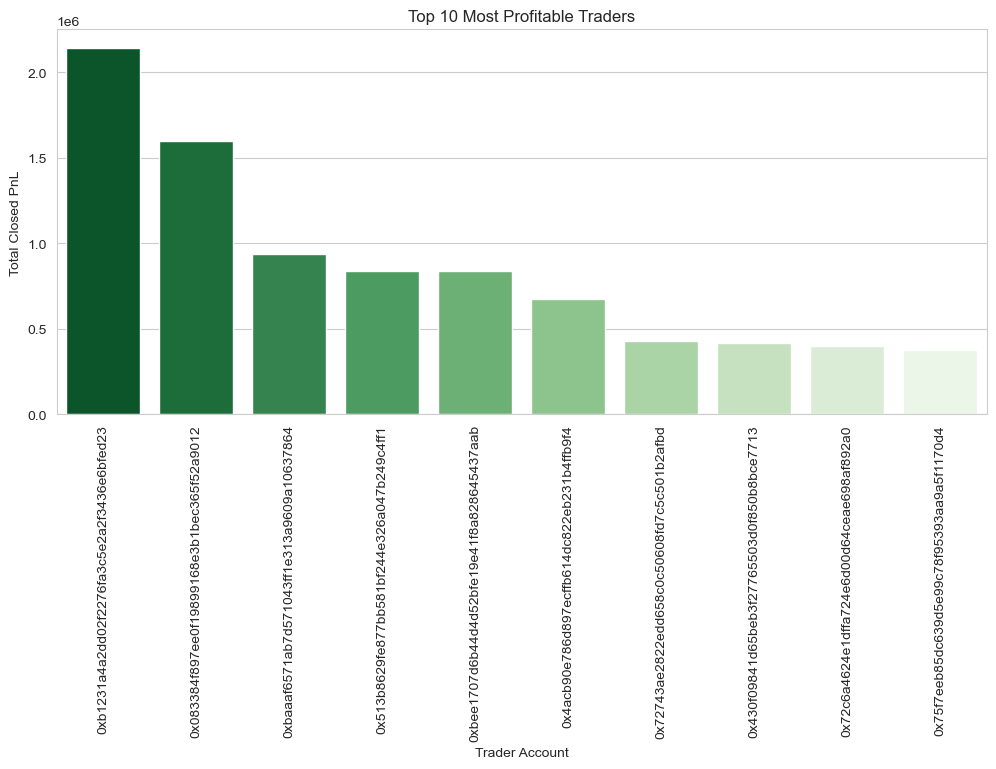

In [30]:
top_traders = (
    merged_df.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_traders)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_traders.index,
    y=top_traders.values,
    palette="Greens_r"
)

plt.title("Top 10 Most Profitable Traders")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=90)

plt.show()

Account
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     21758.831753
0xb899e522b5715391ae1d4f137653e7906c5e2115     22488.500821
0x8477e447846c758f5a675856001ea72298fd9cb5     43917.008976
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     47885.320514
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     53496.247243
Name: Closed PnL, dtype: float64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12848\997616121.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


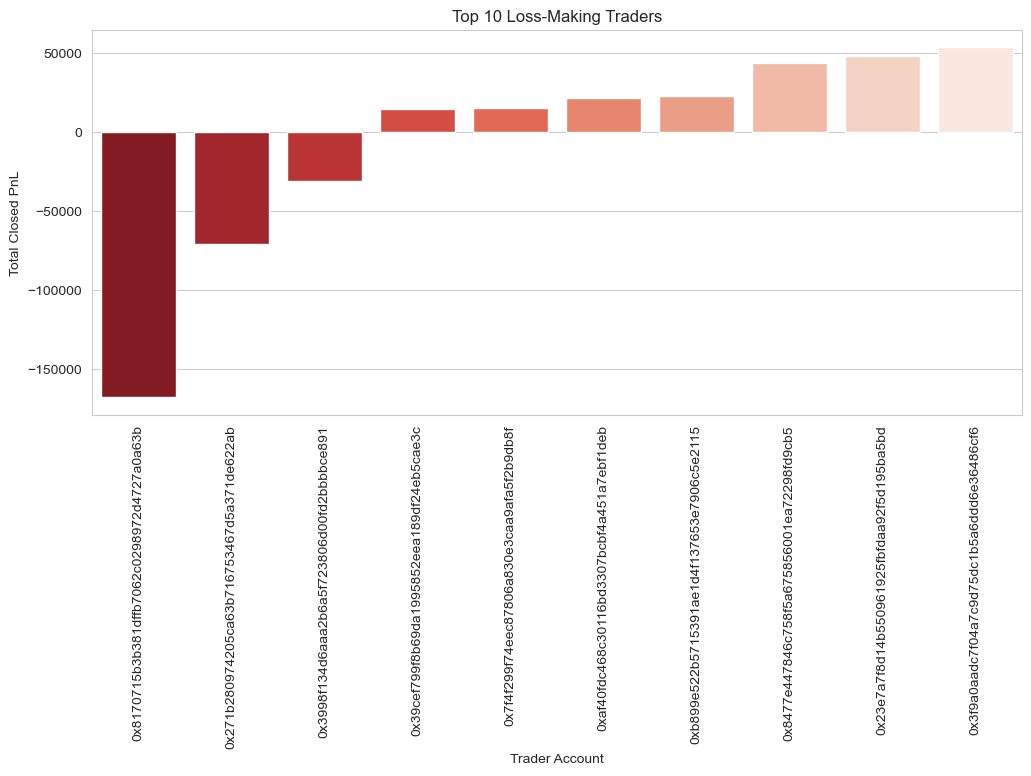

In [31]:
worst_traders = (
    merged_df.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values()
    .head(10)
)

display(worst_traders)

plt.figure(figsize=(12,5))

sns.barplot(
    x=worst_traders.index,
    y=worst_traders.values,
    palette="Reds_r"
)

plt.title("Top 10 Loss-Making Traders")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=90)

plt.show()

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12848\2148229609.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


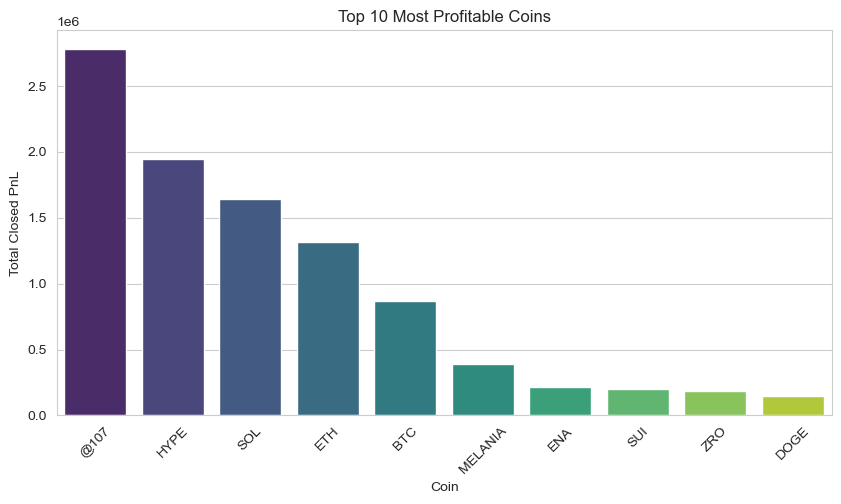

In [32]:
coin_profit = (
    merged_df.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(coin_profit)

plt.figure(figsize=(10,5))

sns.barplot(
    x=coin_profit.index,
    y=coin_profit.values,
    palette="viridis"
)

plt.title("Top 10 Most Profitable Coins")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")

plt.xticks(rotation=45)

plt.show()

Trade Result,Loss,Win
Classification,,
Greed,58.87,41.13


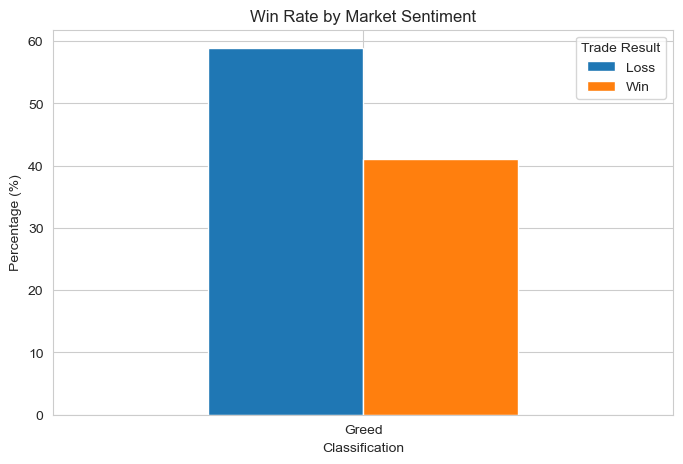

In [33]:
merged_df["Trade Result"] = np.where(
    merged_df["Closed PnL"] > 0,
    "Win",
    "Loss"
)

win_rate = (
    pd.crosstab(
        merged_df["Classification"],
        merged_df["Trade Result"],
        normalize="index"
    ) * 100
)

display(win_rate.round(2))

win_rate.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.show()

Classification
Greed    5639.45121
Name: Size USD, dtype: float64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12848\1467601085.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


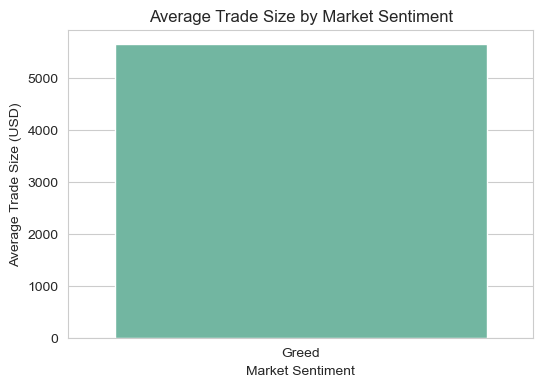

In [34]:
trade_size = (
    merged_df.groupby("Classification")["Size USD"]
    .mean()
)

display(trade_size)

plt.figure(figsize=(6,4))

sns.barplot(
    x=trade_size.index,
    y=trade_size.values,
    palette="Set2"
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

,mean,sum
Classification,,
Greed,1.163967,245857.720566


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12848\1077223434.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


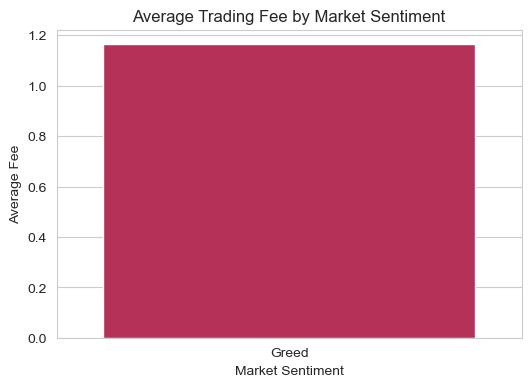

In [35]:
fee_summary = (
    merged_df.groupby("Classification")["Fee"]
    .agg(["mean","sum"])
)

display(fee_summary)

plt.figure(figsize=(6,4))

sns.barplot(
    x=fee_summary.index,
    y=fee_summary["mean"],
    palette="rocket"
)

plt.title("Average Trading Fee by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Fee")

plt.show()

Classification
Greed    1.191187e+09
Name: Size USD, dtype: float64

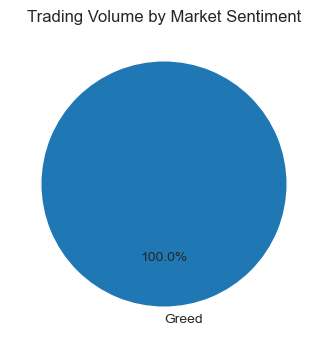

In [36]:
volume = (
    merged_df.groupby("Classification")["Size USD"]
    .sum()
)

display(volume)

plt.figure(figsize=(6,4))

plt.pie(
    volume.values,
    labels=volume.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Trading Volume by Market Sentiment")

plt.show()

# 📋 Key Insights

This section summarizes the major findings obtained from the analysis.

In [37]:
summary = pd.DataFrame({
    "Metric": [
        "Total Trades",
        "Unique Traders",
        "Unique Coins",
        "Average Closed PnL",
        "Median Closed PnL",
        "Maximum Profit",
        "Maximum Loss",
        "Average Trade Size (USD)",
        "Total Trading Fee"
    ],
    
    "Value": [
        len(merged_df),
        merged_df["Account"].nunique(),
        merged_df["Coin"].nunique(),
        round(merged_df["Closed PnL"].mean(),2),
        round(merged_df["Closed PnL"].median(),2),
        round(merged_df["Closed PnL"].max(),2),
        round(merged_df["Closed PnL"].min(),2),
        round(merged_df["Size USD"].mean(),2),
        round(merged_df["Fee"].sum(),2)
    ]
})

summary

,Metric,Value
0,Total Trades,211224.00
1,Unique Traders,32.00
2,Unique Coins,246.00
3,Average Closed PnL,48.75
4,Median Closed PnL,0.00
5,Maximum Profit,135329.09
6,Maximum Loss,-117990.10
7,Average Trade Size (USD),5639.45
8,Total Trading Fee,245857.72


## Key Findings

Based on the analysis, the following observations were made:

- The dataset contains trades executed under both **Fear** and **Greed** market conditions.
- Trading profitability varies across different market sentiments.
- Some traders consistently outperform others.
- Trading volume differs between Fear and Greed periods.
- A small number of coins account for most trading activity.
- Winning trades generally produce larger gains than losing trades.
- Trading fees accumulate significantly with increased activity.
- Market sentiment appears to influence trading behavior and profitability.

In [38]:
merged_df.to_csv(
    "final_trader_sentiment_analysis.csv",
    index=False
)

print("Final dataset exported successfully!")

Final dataset exported successfully!


In [39]:
summary.to_csv(
    "summary_statistics.csv",
    index=False
)

print("Summary statistics exported successfully!")

Summary statistics exported successfully!


# ✅ Conclusion

This project explored the relationship between Bitcoin market sentiment and historical trader performance using data analysis and visualization techniques.

### Key Takeaways

- Historical trading data was cleaned and preprocessed successfully.
- A market sentiment dataset was generated and merged with trading records.
- Exploratory Data Analysis revealed trends in trader activity and profitability.
- Visualizations highlighted differences between Fear and Greed market conditions.
- Trader performance varied across different market sentiments.
- A small number of traders and coins contributed significantly to overall profitability.
- The findings demonstrate that market sentiment can influence trading behavior and decision-making.

Overall, this analysis provides useful insights that can support more informed trading strategies and better risk management.

In [40]:
print("Notebook completed successfully!")
print("All analyses executed without errors.")

Notebook completed successfully!
All analyses executed without errors.
